In [350]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# violation data processing

In [351]:
# loading violation data
violation = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/Environmental_Health_Restaurant_and_Market_Violations.csv"
)

violation = violation[["SERIAL NUMBER", "VIOLATION DESCRIPTION"]]
violation["VIOLATION DESCRIPTION"] = violation["VIOLATION DESCRIPTION"].str.split(
    ".", n=1, expand=True
)[1]
violation["VIOLATION DESCRIPTION"].unique()

array([' FOOD CONTACT SURFACES: CLEAN AND SANITIZED',
       ' NONFOOD-CONTACT SURFACES CLEAN AND IN GOOD REPAIR',
       ' PLUMBING: PLUMBING IN GOOD REPAIR, PROPER BACKFLOW DEVICES',
       ' EQUIPMENT/UTENSILS - APPROVED; INSTALLED; CLEAN; GOOD REPAIR, CAPACITY',
       ' GARBAGE AND REFUSE PROPERLY DISPOSED; FACILITIES MAINTAINED',
       ' FOOD SAFETY CERTIFICATION',
       ' PERSONAL CLEANLINESS AND HAIR RESTRAINTS',
       ' EQUIPMENT, UTENSILS AND LINENS: STORAGE AND USE',
       ' SIGNS POSTED; LAST INSPECTION REPORT AVAILABLE',
       ' THERMOMETERS PROVIDED AND ACCURATE',
       ' WIPING CLOTHS: PROPERLY USED AND STORED',
       ' ADEQUATE VENTILATION AND LIGHTING; DESIGNATED AREAS, USE',
       ' ADEQUATE HANDWASHING FACILITIES SUPPLIED & ACCESSIBLE',
       ' MULTIPLE MAJOR CRITICAL VIOLATIONS / INCREASED RISK TO PUBLIC HEALTH',
       ' PROPER HOT AND COLD HOLDING TEMPERATURES',
       ' FLOORS, WALLS AND CEILINGS: PROPERLY BUILT, MAINTAINED IN GOOD REPAIR AND CLEAN',
   

In [352]:
# Pivot the violation dataset to make it wide by each serial number
violation_wide = violation.pivot_table(
    index="SERIAL NUMBER",
    columns="VIOLATION DESCRIPTION",
    aggfunc=lambda x: 1,
    fill_value=0,
).reset_index()

# Flatten the column names
violation_wide.columns.name = None
violation_wide.columns = [str(col) for col in violation_wide.columns]

violation_wide = violation_wide.drop(columns=[""])

violation_wide

,SERIAL NUMBER,NO HEALTH CODE VIOLATIONS OBSERVED AT THE TIME OF INSPECTION.,ADEQUATE HANDWASHING FACILITIES SUPPLIED & ACCESSIBLE,"ADEQUATE VENTILATION AND LIGHTING; DESIGNATED AREAS, USE","APPROVED THAWING METHODS USED, FROZEN FOOD MAINTAINED FROZEN","COMMUNICABLE DISEASE; REPORTING, RESTRICTIONS & EXCLUSIONS",COMPLIANCE WITH GULF OYSTER REGULATIONS,"COMPLIANCE WITH SHELF STOCK TAGS, CONDITION, DISPLAYED","COMPLIANCE WITH VARIANCE, SPECIALIZED PROCESS, & HACCP PLAN",CONSUMER ADVISORY PROVIDED FOR RAW OR UNDERCOOKED FOODS,...,SEWAGE AND WASTEWATER PROPERLY DISPOSED,SIGNS POSTED; LAST INSPECTION REPORT AVAILABLE,SLEEPING QUARTERS,THERMOMETERS PROVIDED AND ACCURATE,TIME AS A PUBLIC HEALTH CONTROL; PROCEDURES & RECORDS,"TOILET FACILITIES: PROPERLY CONSTRUCTED, SUPPLIED, CLEANED","TOXIC SUBSTANCES PROPERLY IDENTIFIED, STORED, USED","WAREWASHING FACILITIES: ADEQUATE, MAINTAINED, PROPERLY USE, TEST STRIPS AVAILABLE",WATER AVAILABLE,WIPING CLOTHS: PROPERLY USED AND STORED
0,DA000I0AU,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,DA000I8KW,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
2,DA000L0AV,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,DA000L3ZQ,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,DA000Y9WC,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119058,DAZZWLEBW,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,1
119059,DAZZXWDIN,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
119060,DAZZYMC3K,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
119061,DAZZZ9EWK,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# final resturaunt data processing

In [353]:
rest = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/restauranthealthinspections2024_CensusSVIUSDA_halfmileradius.csv",
    encoding="latin-1",
)
rest = rest[rest["State"] == "CA"]
rest

/var/folders/xm/yhmrwng57qq9wlcywlm89pxh0000gn/T/ipykernel_3595/1408986134.py:1: DtypeWarning: Columns (4,7,14,16,17,30,32,33,34,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  rest = pd.read_csv(


,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,USDA_TractSeniors,USDA_TractWhite,USDA_TractBlack,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,199.0,1387.0,138.0,552.0,0.0,49.0,1720.0,2875.0,308.0,151.0
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,481.0,2603.0,287.0,776.0,36.0,16.0,745.0,1218.0,79.0,50.0
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,320.0,835.0,825.0,500.0,5.0,44.0,1244.0,1885.0,154.0,126.0
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,310.0,1760.0,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34289,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,ROUTINE INSPECTION,73.0,C,NaN,2024,...,334.0,2896.0,68.0,285.0,4.0,13.0,351.0,511.0,76.0,0.0
34290,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,ROUTINE INSPECTION,95.0,A,NaN,2024,...,511.0,1674.0,696.0,807.0,41.0,44.0,1705.0,3107.0,96.0,205.0
34291,2024-12-31,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,ROUTINE INSPECTION,91.0,A,STE #D,2024,...,493.0,1880.0,61.0,167.0,0.0,34.0,1022.0,2346.0,63.0,71.0
34292,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,ROUTINE INSPECTION,95.0,A,NaN,2024,...,452.0,1115.0,2080.0,14.0,11.0,26.0,1697.0,2769.0,294.0,400.0


In [354]:
rest.rename(
    columns={
        "INSPECTION_DATE": "ACTIVITY DATE",
        "STORE_NAME": "FACILITY NAME",
        "STREET_ADDRESS": "FACILITY ADDRESS",
    },
    inplace=True,
)
# convert object to string
rest["FACILITY NAME"] = rest["FACILITY NAME"].astype(str)
rest["FACILITY ADDRESS"] = rest["FACILITY ADDRESS"].astype(str)
rest["ACTIVITY DATE"] = rest["ACTIVITY DATE"].astype(str)
rest

,ACTIVITY DATE,FACILITY NAME,FACILITY ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,USDA_TractSeniors,USDA_TractWhite,USDA_TractBlack,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,199.0,1387.0,138.0,552.0,0.0,49.0,1720.0,2875.0,308.0,151.0
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,481.0,2603.0,287.0,776.0,36.0,16.0,745.0,1218.0,79.0,50.0
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,320.0,835.0,825.0,500.0,5.0,44.0,1244.0,1885.0,154.0,126.0
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,310.0,1760.0,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34289,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,ROUTINE INSPECTION,73.0,C,NaN,2024,...,334.0,2896.0,68.0,285.0,4.0,13.0,351.0,511.0,76.0,0.0
34290,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,ROUTINE INSPECTION,95.0,A,NaN,2024,...,511.0,1674.0,696.0,807.0,41.0,44.0,1705.0,3107.0,96.0,205.0
34291,2024-12-31,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,ROUTINE INSPECTION,91.0,A,STE #D,2024,...,493.0,1880.0,61.0,167.0,0.0,34.0,1022.0,2346.0,63.0,71.0
34292,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,ROUTINE INSPECTION,95.0,A,NaN,2024,...,452.0,1115.0,2080.0,14.0,11.0,26.0,1697.0,2769.0,294.0,400.0


# merging raw la county health data with final resturaunt data to get serial number

In [355]:
raw = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/Environmental_Health_Restaurant_and_Market_Inspections.csv",
    encoding="latin-1",
)

/var/folders/xm/yhmrwng57qq9wlcywlm89pxh0000gn/T/ipykernel_3595/1311998555.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(


In [356]:
raw["ACTIVITY YEAR"] = pd.to_datetime(raw["ACTIVITY DATE"]).dt.year
raw["ACTIVITY DATE"] = pd.to_datetime(raw["ACTIVITY DATE"]).dt.date
raw = raw[raw["ACTIVITY YEAR"] == 2024].copy()
raw

,ACTIVITY DATE,OWNER ID,OWNER NAME,FACILITY ID,FACILITY NAME,RECORD ID,PROGRAM NAME,PROGRAM STATUS,PROGRAM ELEMENT,PE DESCRIPTION,...,FACILITY CITY,FACILITY STATE,FACILITY ZIP,SERVICE CODE,SERVICE DESCRIPTION,SCORE,GRADE,SERIAL NUMBER,EMPLOYEE ID,ACTIVITY YEAR
75679,2024-01-02,OW0003061,ARMEHR CORP,FA0001982,3RD ST CHEVRON,PR0033689,3RD ST CHEVRON,ACTIVE,1610,"FOOD MKT RETAIL (1-1,999 SF) LOW RISK",...,LOS ANGELES,CA,90020,1,ROUTINE INSPECTION,90,A,DA3706837,EE0001194,2024
75680,2024-01-02,OW0101428,"MACHT, INC",FA0138020,7-ELEVEN #34473B,PR0122249,7-ELEVEN,ACTIVE,1611,"FOOD MKT RETAIL (1-1,999 SF) MODERATE RISK",...,LAKEWOOD,CA,90713,1,ROUTINE INSPECTION,97,A,DA3704723,EE0001134,2024
75681,2024-01-02,OW0032658,"SHIN, JOHN H",FA0002328,7-ELEVEN #39023B,PR0040055,7-ELEVEN STORE 39023B,ACTIVE,1610,"FOOD MKT RETAIL (1-1,999 SF) LOW RISK",...,LOS ANGELES,CA,90019,1,ROUTINE INSPECTION,96,A,DA3706152,EE0001289,2024
75682,2024-01-02,OW0181958,ALI ENTERPRISES INC #2,FA0175400,7-ELEVEN #39714,PR0168544,7-ELEVEN #39714,ACTIVE,1610,"FOOD MKT RETAIL (1-1,999 SF) LOW RISK",...,LOS ANGELES,CA,90028,1,ROUTINE INSPECTION,94,A,DA3707006,EE0001291,2024
75683,2024-01-02,OW0249212,GEORGIO BENTIN GROUP LLC,FA0256529,AEIRLOOM-CATCHER,PR0206325,AEIRLOOM-CATCHER,ACTIVE,1638,RESTAURANT (61-150) SEATS HIGH RISK,...,NORTH HOLLYWOOD,CA,91602,1,ROUTINE INSPECTION,92,A,DA3706393,EE0001112,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113317,2024-12-31,OW0010700,"STANDARD STATION SPORTS BAR AND GRILL, INC",FA0048544,STANDARD STATIONS SPORTS BAR,PR0036979,STANDARD STATIONS SPORTS BAR,ACTIVE,1635,RESTAURANT (31-60) SEATS HIGH RISK,...,EL SEGUNDO,CA,90245,1,ROUTINE INSPECTION,73,C,DA4726167,EE0001502,2024
113318,2024-12-31,OW0099682,"SUBWAY R US, INC",FA0137466,SUBWAY,PR0121528,SUBWAY,ACTIVE,1631,RESTAURANT (0-30) SEATS MODERATE RISK,...,GARDENA,CA,90247,1,ROUTINE INSPECTION,95,A,DA4728323,EE0001479,2024
113319,2024-12-31,OW0181632,"ELAS, LLC",FA0049918,SUBWAY #3675,PR0039816,SUBWAY #3675,ACTIVE,1631,RESTAURANT (0-30) SEATS MODERATE RISK,...,SOUTH GATE,CA,90280,1,ROUTINE INSPECTION,91,A,DA4726629,EE0001261,2024
113320,2024-12-31,OW0029941,"RELIANCE RESTAURANTS, LLC",FA0049285,SUBWAY #44267,PR0007804,SUBWAY #44267,ACTIVE,1631,RESTAURANT (0-30) SEATS MODERATE RISK,...,LOS ANGELES,CA,90044,1,ROUTINE INSPECTION,95,A,DA4728498,EE0001479,2024


In [357]:
raw["FACILITY NAME"] = raw["FACILITY NAME"].astype(str)
raw["FACILITY ADDRESS"] = raw["FACILITY ADDRESS"].astype(str)
raw["ACTIVITY DATE"] = raw["ACTIVITY DATE"].astype(str)
raw

,ACTIVITY DATE,OWNER ID,OWNER NAME,FACILITY ID,FACILITY NAME,RECORD ID,PROGRAM NAME,PROGRAM STATUS,PROGRAM ELEMENT,PE DESCRIPTION,...,FACILITY CITY,FACILITY STATE,FACILITY ZIP,SERVICE CODE,SERVICE DESCRIPTION,SCORE,GRADE,SERIAL NUMBER,EMPLOYEE ID,ACTIVITY YEAR
75679,2024-01-02,OW0003061,ARMEHR CORP,FA0001982,3RD ST CHEVRON,PR0033689,3RD ST CHEVRON,ACTIVE,1610,"FOOD MKT RETAIL (1-1,999 SF) LOW RISK",...,LOS ANGELES,CA,90020,1,ROUTINE INSPECTION,90,A,DA3706837,EE0001194,2024
75680,2024-01-02,OW0101428,"MACHT, INC",FA0138020,7-ELEVEN #34473B,PR0122249,7-ELEVEN,ACTIVE,1611,"FOOD MKT RETAIL (1-1,999 SF) MODERATE RISK",...,LAKEWOOD,CA,90713,1,ROUTINE INSPECTION,97,A,DA3704723,EE0001134,2024
75681,2024-01-02,OW0032658,"SHIN, JOHN H",FA0002328,7-ELEVEN #39023B,PR0040055,7-ELEVEN STORE 39023B,ACTIVE,1610,"FOOD MKT RETAIL (1-1,999 SF) LOW RISK",...,LOS ANGELES,CA,90019,1,ROUTINE INSPECTION,96,A,DA3706152,EE0001289,2024
75682,2024-01-02,OW0181958,ALI ENTERPRISES INC #2,FA0175400,7-ELEVEN #39714,PR0168544,7-ELEVEN #39714,ACTIVE,1610,"FOOD MKT RETAIL (1-1,999 SF) LOW RISK",...,LOS ANGELES,CA,90028,1,ROUTINE INSPECTION,94,A,DA3707006,EE0001291,2024
75683,2024-01-02,OW0249212,GEORGIO BENTIN GROUP LLC,FA0256529,AEIRLOOM-CATCHER,PR0206325,AEIRLOOM-CATCHER,ACTIVE,1638,RESTAURANT (61-150) SEATS HIGH RISK,...,NORTH HOLLYWOOD,CA,91602,1,ROUTINE INSPECTION,92,A,DA3706393,EE0001112,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113317,2024-12-31,OW0010700,"STANDARD STATION SPORTS BAR AND GRILL, INC",FA0048544,STANDARD STATIONS SPORTS BAR,PR0036979,STANDARD STATIONS SPORTS BAR,ACTIVE,1635,RESTAURANT (31-60) SEATS HIGH RISK,...,EL SEGUNDO,CA,90245,1,ROUTINE INSPECTION,73,C,DA4726167,EE0001502,2024
113318,2024-12-31,OW0099682,"SUBWAY R US, INC",FA0137466,SUBWAY,PR0121528,SUBWAY,ACTIVE,1631,RESTAURANT (0-30) SEATS MODERATE RISK,...,GARDENA,CA,90247,1,ROUTINE INSPECTION,95,A,DA4728323,EE0001479,2024
113319,2024-12-31,OW0181632,"ELAS, LLC",FA0049918,SUBWAY #3675,PR0039816,SUBWAY #3675,ACTIVE,1631,RESTAURANT (0-30) SEATS MODERATE RISK,...,SOUTH GATE,CA,90280,1,ROUTINE INSPECTION,91,A,DA4726629,EE0001261,2024
113320,2024-12-31,OW0029941,"RELIANCE RESTAURANTS, LLC",FA0049285,SUBWAY #44267,PR0007804,SUBWAY #44267,ACTIVE,1631,RESTAURANT (0-30) SEATS MODERATE RISK,...,LOS ANGELES,CA,90044,1,ROUTINE INSPECTION,95,A,DA4728498,EE0001479,2024


In [358]:
# Merge the SERIAL NUMBER column from the raw dataset to the rest dataset
rest_wserial = rest.merge(
    raw[["SERIAL NUMBER", "ACTIVITY DATE", "FACILITY NAME", "FACILITY ADDRESS"]],
    on=["ACTIVITY DATE", "FACILITY NAME", "FACILITY ADDRESS"],
    how="inner",
)
rest_wserial

,ACTIVITY DATE,FACILITY NAME,FACILITY ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,USDA_TractWhite,USDA_TractBlack,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP,SERIAL NUMBER
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,1387.0,138.0,552.0,0.0,49.0,1720.0,2875.0,308.0,151.0,DA3706837
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,2603.0,287.0,776.0,36.0,16.0,745.0,1218.0,79.0,50.0,DA3704723
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,835.0,825.0,500.0,5.0,44.0,1244.0,1885.0,154.0,126.0,DA3706152
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,1760.0,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0,DA3707006
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DA3706393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34399,2024-12-31,MEGA NADEE LIQUOR STORE,863 S VERMONT AVE,LOS ANGELES,90005.0,ROUTINE INSPECTION,100.0,A,NaN,2024,...,694.0,55.0,1395.0,1.0,15.0,892.0,1481.0,260.0,135.0,DA4727186
34400,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,ROUTINE INSPECTION,73.0,C,NaN,2024,...,2896.0,68.0,285.0,4.0,13.0,351.0,511.0,76.0,0.0,DA4726167
34401,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,ROUTINE INSPECTION,95.0,A,NaN,2024,...,1674.0,696.0,807.0,41.0,44.0,1705.0,3107.0,96.0,205.0,DA4728323
34402,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,ROUTINE INSPECTION,95.0,A,NaN,2024,...,1115.0,2080.0,14.0,11.0,26.0,1697.0,2769.0,294.0,400.0,DA4728498


In [359]:
# merge the violation_wide dataset to the rest_wserial dataset
final = rest_wserial.merge(
    violation_wide,
    on="SERIAL NUMBER",
    how="inner",
)

# Drop unnecessary columns by their indices and the "SERIAL NUMBER" column
final = final.drop(final.columns[list(range(0, 6)) + list(range(8, 35))], axis=1).drop(
    columns=["SERIAL NUMBER"]
)

In [360]:
# Feature selection
# get index of the columns of these variable names
cols = [
    "GRADE",
    "SCORE",
    "EP_UNEMP",
    "EP_HBURD",
    "EP_NOHSDP",
    "EP_UNINSUR",
    "EP_AGE65",
    "EP_AGE17",
    "EP_DISABL",
    "EP_SNGPNT",
    "EP_LIMENG",
    "EP_MINRTY",
    "EP_MUNIT",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_NOVEH",
    "EP_GROUPQ",
    "USDA_PovertyRate",
    "USDA_MedianFamilyIncome",
    "USDA_PCTGQTRS",
    "USDA_TractSNAP",
]
# get the index of the columns
cols_index = [final.columns.get_loc(col) for col in cols]
cols_index

[1,
 0,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 125,
 126,
 118,
 256]

In [361]:
# keep the columns by their indices and all columns after column 256
final = final.iloc[:, cols_index + list(range(256, final.shape[1]))]
final = final.dropna()
final

,GRADE,SCORE,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,...,SEWAGE AND WASTEWATER PROPERLY DISPOSED,SIGNS POSTED; LAST INSPECTION REPORT AVAILABLE,SLEEPING QUARTERS,THERMOMETERS PROVIDED AND ACCURATE,TIME AS A PUBLIC HEALTH CONTROL; PROCEDURES & RECORDS,"TOILET FACILITIES: PROPERLY CONSTRUCTED, SUPPLIED, CLEANED","TOXIC SUBSTANCES PROPERLY IDENTIFIED, STORED, USED","WAREWASHING FACILITIES: ADEQUATE, MAINTAINED, PROPERLY USE, TEST STRIPS AVAILABLE",WATER AVAILABLE,WIPING CLOTHS: PROPERLY USED AND STORED
0,A,90.0,9.2,58.2,27.0,20.5,8.4,20.5,5.4,11.3,...,0,0,0,0,0,1,0,1,0,0
1,A,97.0,9.0,21.2,14.0,2.6,13.6,17.0,9.4,5.7,...,0,0,0,0,0,0,0,0,0,0
2,A,96.0,14.5,48.5,24.9,20.1,11.4,20.9,9.6,11.2,...,0,0,0,0,0,0,0,0,0,0
3,A,94.0,9.5,43.6,7.6,10.1,6.8,9.1,9.9,1.2,...,0,0,0,0,0,0,0,0,0,1
5,A,97.0,9.5,43.6,7.6,10.1,6.8,9.1,9.9,1.2,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33339,A,98.0,1.6,21.5,1.9,1.1,33.5,9.6,7.3,0.0,...,0,0,0,0,0,0,0,0,0,0
33340,C,73.0,6.1,14.4,1.2,3.1,12.7,13.9,8.7,4.2,...,0,0,0,1,0,1,0,0,0,0
33341,A,95.0,3.0,44.8,19.9,10.8,12.7,15.4,19.6,9.1,...,0,0,0,0,0,0,0,1,0,1
33342,A,95.0,3.0,50.2,30.7,8.9,11.1,26.9,16.2,9.9,...,0,0,0,0,0,0,0,0,0,0


In [362]:
final_grade = final.drop(columns=["SCORE"])
final_grade

,GRADE,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,EP_LIMENG,...,SEWAGE AND WASTEWATER PROPERLY DISPOSED,SIGNS POSTED; LAST INSPECTION REPORT AVAILABLE,SLEEPING QUARTERS,THERMOMETERS PROVIDED AND ACCURATE,TIME AS A PUBLIC HEALTH CONTROL; PROCEDURES & RECORDS,"TOILET FACILITIES: PROPERLY CONSTRUCTED, SUPPLIED, CLEANED","TOXIC SUBSTANCES PROPERLY IDENTIFIED, STORED, USED","WAREWASHING FACILITIES: ADEQUATE, MAINTAINED, PROPERLY USE, TEST STRIPS AVAILABLE",WATER AVAILABLE,WIPING CLOTHS: PROPERLY USED AND STORED
0,A,9.2,58.2,27.0,20.5,8.4,20.5,5.4,11.3,18.8,...,0,0,0,0,0,1,0,1,0,0
1,A,9.0,21.2,14.0,2.6,13.6,17.0,9.4,5.7,5.5,...,0,0,0,0,0,0,0,0,0,0
2,A,14.5,48.5,24.9,20.1,11.4,20.9,9.6,11.2,14.0,...,0,0,0,0,0,0,0,0,0,0
3,A,9.5,43.6,7.6,10.1,6.8,9.1,9.9,1.2,7.3,...,0,0,0,0,0,0,0,0,0,1
5,A,9.5,43.6,7.6,10.1,6.8,9.1,9.9,1.2,7.3,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33339,A,1.6,21.5,1.9,1.1,33.5,9.6,7.3,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
33340,C,6.1,14.4,1.2,3.1,12.7,13.9,8.7,4.2,1.0,...,0,0,0,1,0,1,0,0,0,0
33341,A,3.0,44.8,19.9,10.8,12.7,15.4,19.6,9.1,14.3,...,0,0,0,0,0,0,0,1,0,1
33342,A,3.0,50.2,30.7,8.9,11.1,26.9,16.2,9.9,16.8,...,0,0,0,0,0,0,0,0,0,0


In [363]:
# for the GRADE dataset (multinomial logistic regression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    label_binarize,
)


X = final_grade.drop("GRADE", axis=1)
y = final_grade[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# train/test split
X_train_grade, X_test_grade, y_train_grade, y_test_grade = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_grade_scaled = scaler.fit_transform(X_train_grade)
X_test_grade_scaled = scaler.fit_transform(X_test_grade)
# scaler = StandardScaler()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [364]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# ABOUT THE LOGISTIC REGRESSION MODEL:
# creating multinomial logistic regression model
# testing other solvers, but apparently, 'lbfgs' is "great for multinomial"
# liblinear only handles binary classification, so we'll test for that later
# doing l2 penalty b/c only liblinear is compatible with l1 and l2

# ABOUT THE OneVsRestClassifier:
# Fits one classifier, LR in this case, per class, used in multiclass logistic regression
# will help us calculate ROC/AUC score and PR for each class relative to the others
# this is why we binarized the labels (e.g. for class A, the negative class is class B and C)
# aka we are translating multinomial log reg = multiple binary classification tasks, one per class
LR = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        penalty="l2",
        solver="lbfgs",
    )
)

In [365]:
LR.fit(X_train_grade_scaled, y_train_grade)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000,
                                                 multi_class='multinomial'))

In [366]:
# predicting confidence scores
LR_y_pred = LR.predict_proba(X_test_grade_scaled)

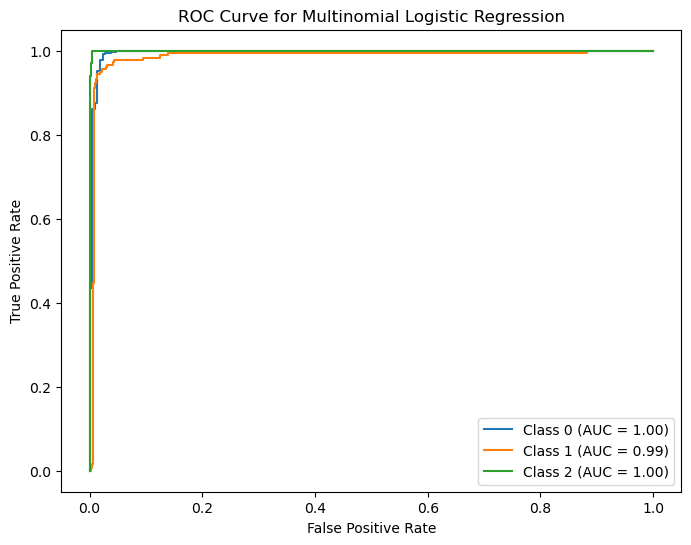

In [367]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way
import matplotlib.pyplot as plt
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], LR_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression")
plt.legend()
plt.show()

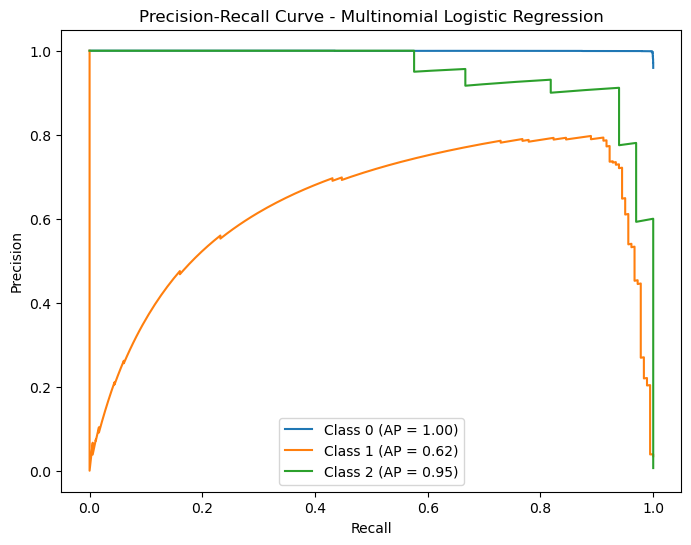

In [368]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], LR_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], LR_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression")
plt.legend()
plt.show()

/var/folders/xm/yhmrwng57qq9wlcywlm89pxh0000gn/T/ipykernel_3595/1018864645.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


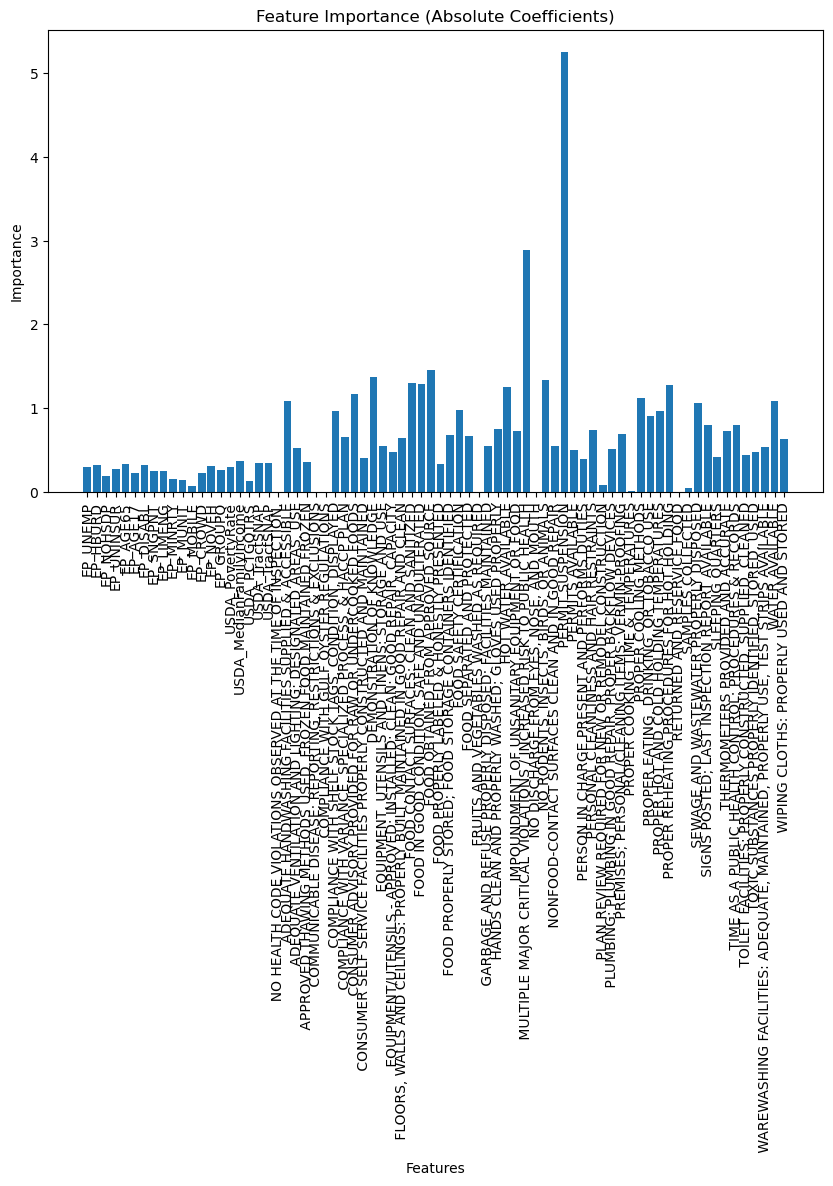

In [369]:
# Get the coefficients for each class
coefficients = LR.estimators_[0].coef_

# Compute the absolute mean of coefficients across all classes
mean_abs_coefficients = np.mean(np.abs(coefficients), axis=0)

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(mean_abs_coefficients)), mean_abs_coefficients, align="center")
plt.xticks(range(len(mean_abs_coefficients)), X.columns, rotation=90)
plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [370]:
final_grade.columns

Index(['GRADE', 'EP_UNEMP', 'EP_HBURD', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65',
       'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_LIMENG', 'EP_MINRTY',
       'EP_MUNIT', 'EP_MOBILE', 'EP_CROWD', 'EP_NOVEH', 'EP_GROUPQ',
       'USDA_PovertyRate', 'USDA_MedianFamilyIncome', 'USDA_PCTGQTRS',
       'USDA_TractSNAP', 'USDA_TractSNAP',
       '  NO HEALTH CODE VIOLATIONS OBSERVED AT THE TIME OF INSPECTION.',
       ' ADEQUATE HANDWASHING FACILITIES SUPPLIED & ACCESSIBLE',
       ' ADEQUATE VENTILATION AND LIGHTING; DESIGNATED AREAS, USE',
       ' APPROVED THAWING METHODS USED, FROZEN FOOD MAINTAINED FROZEN',
       ' COMMUNICABLE DISEASE; REPORTING, RESTRICTIONS & EXCLUSIONS',
       ' COMPLIANCE WITH GULF OYSTER REGULATIONS',
       ' COMPLIANCE WITH SHELF STOCK TAGS, CONDITION, DISPLAYED',
       ' COMPLIANCE WITH VARIANCE, SPECIALIZED PROCESS, & HACCP PLAN',
       ' CONSUMER ADVISORY PROVIDED FOR RAW OR UNDERCOOKED FOODS',
       ' CONSUMER SELF SERVICE FACILITIES PROPERLY CONSTRUCTED 

In [371]:
final_grade = final_grade.drop(
    columns=[
        " PERMIT SUSPENSION",
        " MULTIPLE MAJOR CRITICAL VIOLATIONS / INCREASED RISK TO PUBLIC HEALTH",
    ]
)

In [372]:
# for the GRADE dataset (multinomial logistic regression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    label_binarize,
)


X = final_grade.drop("GRADE", axis=1)
y = final_grade[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# train/test split
X_train_grade, X_test_grade, y_train_grade, y_test_grade = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_grade_scaled = scaler.fit_transform(X_train_grade)
X_test_grade_scaled = scaler.fit_transform(X_test_grade)
# scaler = StandardScaler()
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# creating multinomial logistic regression model
LR = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        penalty="l2",
        solver="lbfgs",
    )
)
LR.fit(X_train_grade_scaled, y_train_grade)
# predicting confidence scores
LR_y_pred = LR.predict_proba(X_test_grade_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


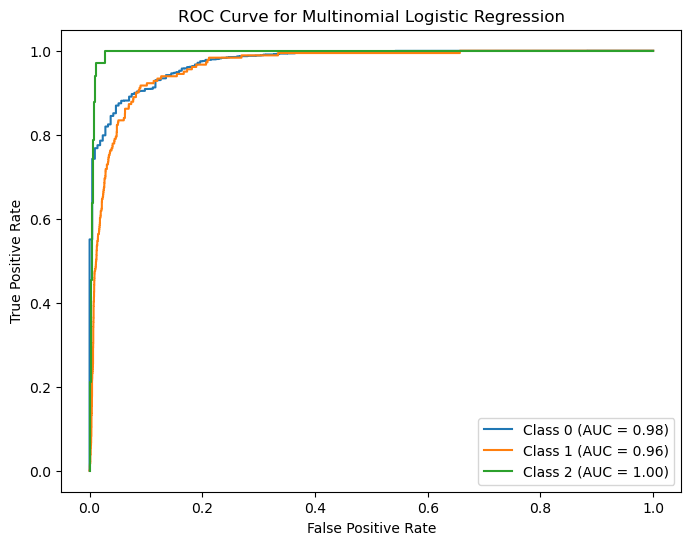

In [373]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way
import matplotlib.pyplot as plt
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], LR_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression")
plt.legend()
plt.show()

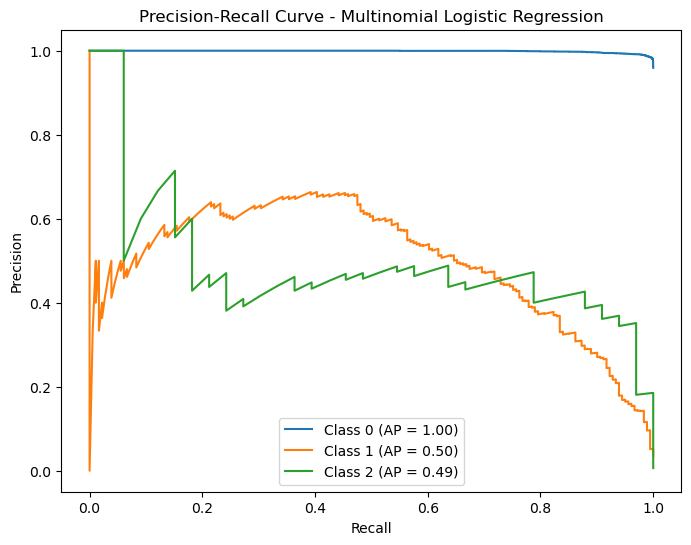

In [374]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], LR_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], LR_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression")
plt.legend()
plt.show()

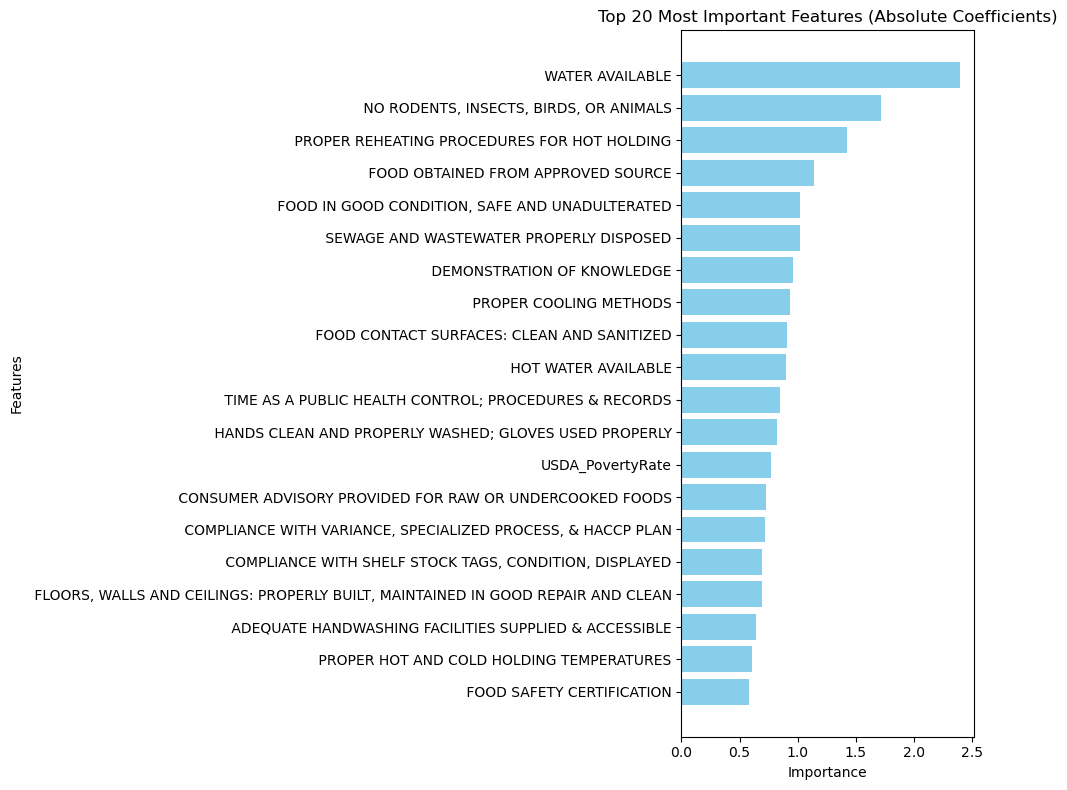

In [376]:
# Get the coefficients for each class
coefficients = LR.estimators_[0].coef_

# Compute the absolute mean of coefficients across all classes
mean_abs_coefficients = np.mean(np.abs(coefficients), axis=0)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": mean_abs_coefficients}
)

# Sort by importance and select the top 20 features
top_features = feature_importance.sort_values(by="Importance", ascending=False).head(20)

# Plot the feature importance as a horizontal bar graph
plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"], top_features["Importance"], color="skyblue")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features (Absolute Coefficients)")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.tight_layout()
plt.show()